In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/amazon.csv')
print(df.shape)
df.head()

(1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
print("Filas y columnas:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())

Filas y columnas: (1465, 16)

Columnas: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']

Tipos de datos:
product_id             str
product_name           str
category               str
discounted_price       str
actual_price           str
discount_percentage    str
rating                 str
rating_count           str
about_product          str
user_id                str
user_name              str
review_id              str
review_title           str
review_content         str
img_link               str
product_link           str
dtype: object

Valores nulos:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id     

In [4]:
# Limpiar precios (sacar ₹ y comas)
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

# Limpiar porcentaje (sacar %)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

# Limpiar rating (algunos valores raros)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Limpiar rating_count (sacar comas)
df['rating_count'] = df['rating_count'].str.replace(',', '').astype(float)

# Categoría principal (primer nivel)
df['main_category'] = df['category'].str.split('|').str[0]

print("Listo! Tipos actualizados:")
print(df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].dtypes)

Listo! Tipos actualizados:
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
dtype: object


In [5]:
# Estadísticas básicas de columnas numéricas
print("=== Estadísticas básicas ===")
print(df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].describe())

print("\n=== Categorías principales ===")
print(df['main_category'].value_counts())

=== Estadísticas básicas ===
       discounted_price   actual_price  discount_percentage       rating  \
count       1465.000000    1465.000000          1465.000000  1464.000000   
mean        3125.310874    5444.990635            47.691468     4.096585   
std         6944.304394   10874.826864            21.635905     0.291674   
min           39.000000      39.000000             0.000000     2.000000   
25%          325.000000     800.000000            32.000000     4.000000   
50%          799.000000    1650.000000            50.000000     4.100000   
75%         1999.000000    4295.000000            63.000000     4.300000   
max        77990.000000  139900.000000            94.000000     5.000000   

        rating_count  
count    1463.000000  
mean    18295.541353  
std     42753.864952  
min         2.000000  
25%      1186.000000  
50%      5179.000000  
75%     17336.500000  
max    426973.000000  

=== Categorías principales ===
main_category
Electronics              526
Comp

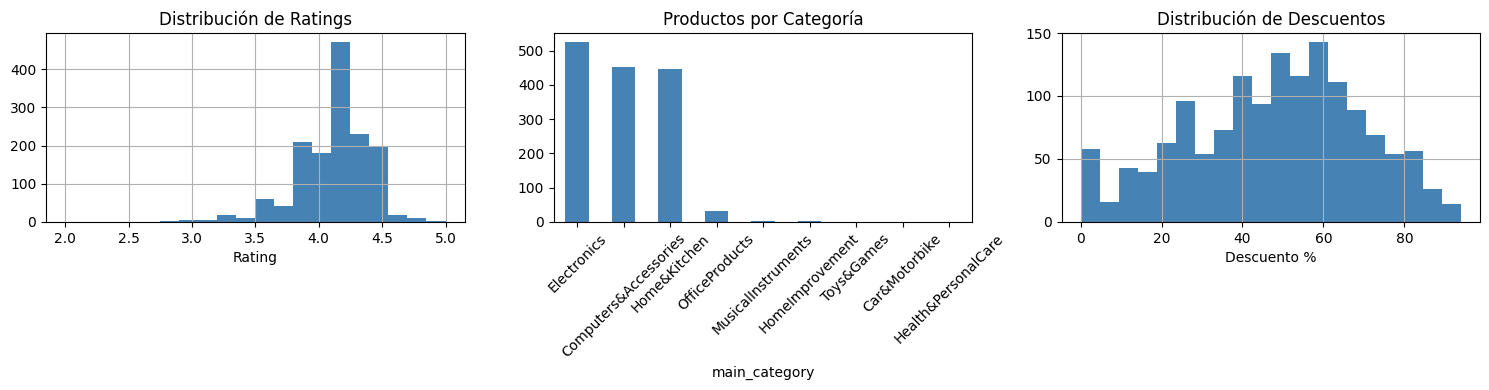

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución de ratings
df['rating'].hist(bins=20, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Ratings')
axes[0].set_xlabel('Rating')

# Productos por categoría
df['main_category'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Productos por Categoría')
axes[1].tick_params(axis='x', rotation=45)

# Distribución de descuentos
df['discount_percentage'].hist(bins=20, ax=axes[2], color='steelblue')
axes[2].set_title('Distribución de Descuentos')
axes[2].set_xlabel('Descuento %')

plt.tight_layout()
plt.show()

## Conclusiones del EDA

- La mayoría de productos tienen ratings entre 3.8 y 4.5 estrellas
- Los descuentos se concentran entre el 40% y 70%
- El dataset está dominado por Electronics y Computers&Accessories

In [7]:
# Ver longitud de las descripciones
df['desc_length'] = df['about_product'].str.len()

print("Longitud promedio de descripciones:", df['desc_length'].mean().round(0))
print("Mínima:", df['desc_length'].min())
print("Máxima:", df['desc_length'].max())

# Ver un ejemplo
print("\n=== Ejemplo de descripción ===")
print(df['about_product'][0])

Longitud promedio de descripciones: 729.0
Mínima: 5
Máxima: 2646

=== Ejemplo de descripción ===
High Compatibility : Compatible With iPhone 12, 11, X/XsMax/Xr ,iPhone 8/8 Plus,iPhone 7/7 Plus,iPhone 6s/6s Plus,iPhone 6/6 Plus,iPhone 5/5s/5c/se,iPad Pro,iPad Air 1/2,iPad mini 1/2/3,iPod nano7,iPod touch and more apple devices.|Fast Charge&Data Sync : It can charge and sync simultaneously at a rapid speed, Compatible with any charging adaptor, multi-port charging station or power bank.|Durability : Durable nylon braided design with premium aluminum housing and toughened nylon fiber wound tightly around the cord lending it superior durability and adding a bit to its flexibility.|High Security Level : It is designed to fully protect your device from damaging excessive current.Copper core thick+Multilayer shielding, Anti-interference, Protective circuit equipment.|WARRANTY: 12 months warranty and friendly customer services, ensures the long-time enjoyment of your purchase. If you meet any 

In [8]:
# Ver productos con descripción muy corta
cortos = df[df['desc_length'] < 50][['product_name', 'about_product', 'desc_length']]
print(cortos)

                                           product_name  \
132   Saifsmart Outlet Wall Mount Hanger Holder for ...   
145   Airtel DigitalTV DTH Remote SD/HD/HD Recording...   
153   MI Xiaomi USB Type C HYperCharge Cable 6A 100c...   
198   Belkin Apple Certified Lightning to USB Charge...   
217   Posh 1.5 Meter High Speed Gold Plated HDMI Mal...   
424   MI Xiaomi 22.5W Fast USB Type C Charger Combo ...   
666   Zodo 8. 5 inch LCD E-Writer Electronic Writing...   
887   Camel Artist Acrylic Color Box - 9ml Tubes, 12...   
889   Portronics Key2 Combo Multimedia USB Wireless ...   
1182  Coway Professional Air Purifier for Home, Long...   
1275  Multifunctional 2 in 1 Electric Egg Boiling St...   
1341  Bajaj Majesty Duetto Gas 6 Ltr Vertical Water ...   
1344  Longway Blaze 2 Rod Quartz Room Heater (White,...   
1382  Lifelong LLMG74 750 Watt Mixer Grinder with 3 ...   
1424         KENT POWP-Sediment Filter 10'' Thread WCAP   
1440         Eco Crystal J 5 inch Cartridge (Pack of 2) 

In [9]:
# Combinar nombre + categoría + descripción en un solo campo de texto
df['texto_modelo'] = (
    df['product_name'] + ' ' +
    df['main_category'] + ' ' +
    df['about_product']
)

print("Ejemplo de texto_modelo:")
print(df['texto_modelo'][0][:300])

Ejemplo de texto_modelo:
Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey) Computers&Accessories High Compatibility : Compatible With iPhone 12, 11, X/XsMax/Xr ,iPhone 8/8 Plus,iPhone 7/7 Plus,iPhone 6s/6s Plus,i


##Lo que encontramos en el EDA:

-1465 productos, casi sin nulos
-Precios, ratings y descuentos estaban como texto — ya los limpiamos
-Ratings concentrados entre 3.8 y 4.5 — dataset sesgado hacia lo positivo
-3 categorías dominantes: Electronics, Computers&Accessories, Home&Kitchen
-18 productos con descripción muy corta — lo resolvimos combinando nombre + categoría + descripción
-El campo texto_modelo está listo para alimentar el TF-IDF